## Droplet dynamics - Laminar to turbulent flow 

### References: 
#### 1. Binary-fluid turbulence: Signatures of multifractal droplet dynamics and dissipation reduction
#### 2. Spatiotemporal dynamics in two-dimensional Kolmogorov flow over large domains


Reference: Binary-fluid turbulence: Signatures of multifractal droplet dynamics and dissipation reduction
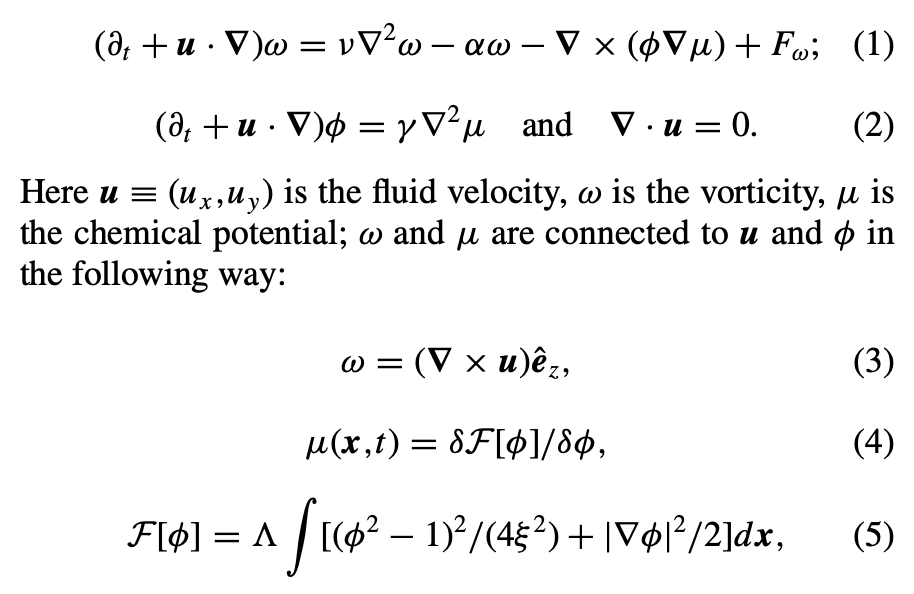
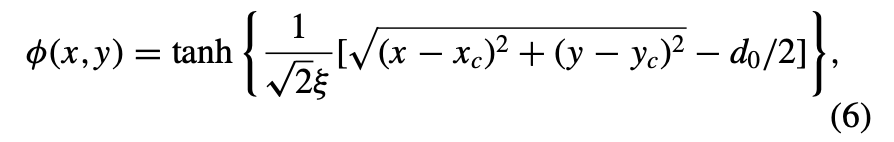

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime
from IPython.display import HTML


In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx 

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0.04
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 1e-5
# 6e-4

# Low sigma could break the interface
sigma = 1.0

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 0.30
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 2

# Forcing
f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
f_w_hat = np.fft.fft2(f_w)

T = 20.0
N_t = 10000
# delta_t = T/N_t
save_every = 100

# Single droplet parameters

xc = 0.35 * L_x
yc = 0.55 * L_y

droplet_radius = 0.10 * L_x  

coupling = True
evolve_phi = True

target_Re_values = [5, 10, 20, 40]

In [3]:
# File names
experiment_name = "Experiment_DD_deformation_experiment"
parameter_name = "parameter_deformation_exp"

# fully_coupled_omega_with_contour = "fully_coupled_omega_with_contour_Re.gif"
# fully_coupled_phi = "fully_coupled_phi_Re.gif"
# validation_summary_fig = "validation_summary_fig_Re"
# flow_transition_fig = "flow_transition_fig_Re"
# droplet_motion_fig = "droplet_response_fig_Re"

In [4]:
# Calculation of Reynold's number

def reynolds_number(f_0, nu, k_f):
    U = f_0 / (nu * k_f**2)
    L = 1.0 / k_f
    return U * L / nu

def nu_from_reynolds(Re, f_0, k_f):
    return np.sqrt(f_0 / (Re * k_f**3))

def make_flow_parameters(nu, f_0, k_f, alpha):

    lamda_01 = -nu * K2 - alpha
    f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
    f_w_hat = np.fft.fft2(f_w)
    Re = reynolds_number(f_0, nu, k_f)

    return lamda_01, f_w, f_w_hat, Re

sweep_table = pd.DataFrame({
    "Re_target": target_Re_values,
    "nu": [nu_from_reynolds(Re, f_0, k_f) for Re in target_Re_values],
})

print(sweep_table)

   Re_target        nu
0          5  0.086603
1         10  0.061237
2         20  0.043301
3         40  0.030619


In [5]:
def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [6]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "Full CHNS regime: NS flow is active, CH phase equation is active, droplet is advected by the flow, interfacial force feeds back into the flow",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        "type": "Kolmogorov-type forcing",
        "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * cos(k_f * Y)",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        # "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },


    # Droplet initial condition
    "initial_condition": {
        "type": "single droplet",
        "xc": float(xc),
        "yc": float(yc),
        "center_definition": "xc = L_x / 2, yc = L_y / 2",
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / f"{parameter_name}.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_deformation_experiment/parameter_deformation_exp.json


In [7]:
def single_droplet_phi(X, Y, xc, yc, R, epsilon):
    """
    Diffuse single-droplet initial condition matching the paper's convention:
        phi < 0 inside droplet
        phi > 0 in background

    Parameters
    ----------
    X, Y : 2D arrays
        Meshgrid arrays.
    xc, yc : float
        Droplet center.
    d0 : float
        Droplet diameter.
    xi : float
        Diffuse interface width parameter from the paper.
    """
    r = np.sqrt((X - xc)**2 + (Y - yc)**2)
    return np.tanh((R - r) / epsilon)

In [8]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

# Assemble \mu using pseudo-spectral implementation

# print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
# print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)

# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [9]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [10]:
# Extraction of droplet geometry from phi

def polygon_area(x, y):
    """
    Shoelace formula for area of a closed polygon.
    """
    return 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_perimeter(x, y, closed=True):
    """
    Perimeter of a polygonal curve.
    """
    if closed:
        dx = np.diff(np.r_[x, x[0]])
        dy = np.diff(np.r_[y, y[0]])
    else:
        dx = np.diff(x)
        dy = np.diff(y)
    return np.sum(np.sqrt(dx**2 + dy**2))


def contour_pixels_to_physical(contour_rc, dx, dy):
    """
    skimage.find_contours returns coordinates as (row, col).
    Convert to physical x,y coordinates.
    """
    r = contour_rc[:, 0]
    c = contour_rc[:, 1]
    x = c * dx
    y = r * dy
    return x, y


def effective_diameter_from_area(A):
    """
    d_p = 2 * sqrt(A / pi)
    """
    return 2.0 * np.sqrt(A / np.pi)


def reference_circle_perimeter_from_area(A):
    """
    Perimeter of a circle with the same area A.
    S0 = pi * d_p = 2 * sqrt(pi A)
    """
    return 2.0 * np.sqrt(np.pi * A)


def deformation_parameter(S, A):
    """
    Gamma = S / S0 - 1
    """
    S0 = reference_circle_perimeter_from_area(A)
    return S / S0 - 1.0


def periodic_center_of_mass(mask, Lx, Ly):
    """
    Periodic-safe center of mass of a boolean mask.
    This avoids jumps when the droplet crosses the periodic boundary.
    """
    Ny, Nx = mask.shape

    # x coordinates
    x_idx = np.arange(Nx)
    theta_x = 2.0 * np.pi * x_idx / Nx
    wx = mask.sum(axis=0).astype(float)
    if wx.sum() == 0:
        return np.nan, np.nan

    Cx = np.sum(wx * np.cos(theta_x)) / np.sum(wx)
    Sx = np.sum(wx * np.sin(theta_x)) / np.sum(wx)
    ang_x = np.arctan2(Sx, Cx) % (2.0 * np.pi)
    x_cm = Lx * ang_x / (2.0 * np.pi)

    # y coordinates
    y_idx = np.arange(Ny)
    theta_y = 2.0 * np.pi * y_idx / Ny
    wy = mask.sum(axis=1).astype(float)
    Cy = np.sum(wy * np.cos(theta_y)) / np.sum(wy)
    Sy = np.sum(wy * np.sin(theta_y)) / np.sum(wy)
    ang_y = np.arctan2(Sy, Cy) % (2.0 * np.pi)
    y_cm = Ly * ang_y / (2.0 * np.pi)

    return x_cm, y_cm

def compute_com(phi_xy):
    """
    Droplet centre of mass using Appendix D of the paper.

    Parameters
    ----------
    phi_xy : 2D numpy array
        Phase-field variable phi(x,y).

    Returns
    -------
    X_CM, Y_CM : floats
        Centre-of-mass coordinates in angular units, i.e. in [0, 2*pi).
    """

    # 2D Fourier transform of phi
    phi_hat = np.fft.fft2(phi_xy)

    # NumPy convention:
    # phi_hat[0, 1] is the first Fourier mode in x
    # phi_hat[1, 0] is the first Fourier mode in y

    phi_hat_x = phi_hat[0, 1]
    phi_hat_y = phi_hat[1, 0]

    X_CM = np.arctan2(np.imag(phi_hat_x), np.real(phi_hat_x))
    Y_CM = np.arctan2(np.imag(phi_hat_y), np.real(phi_hat_y))

    # Convert from [-pi, pi] to [0, 2*pi)
    X_CM = X_CM % (2.0 * np.pi)
    Y_CM = Y_CM % (2.0 * np.pi)

    return X_CM, Y_CM


def extract_main_droplet_contour(phi_xy, level=0.0):
    """
    Extract all level-set contours and return the longest one.
    For a single-droplet setup, this is usually the main droplet boundary.
    """
    contours = measure.find_contours(phi_xy, level=level)

    if len(contours) == 0:
        return None

    # choose the longest contour in number of points
    contour = max(contours, key=lambda c: c.shape[0])
    return contour

def compute_free_energy(phi_xy, dx, dy, sigma, epsilon):
    """
    Free energy functional:

    F(phi) = ∫ [ 3/16 * sigma/epsilon * (phi^2 - 1)^2
               + 3/4 * sigma * epsilon * |grad phi|^2 ] dA
    """

    dphi_dy, dphi_dx = np.gradient(phi_xy, dy, dx)

    bulk = (3.0 / 16.0) * (sigma / epsilon) * (phi_xy**2 - 1.0)**2
    interface = (3.0 / 4.0) * sigma * epsilon * (dphi_dx**2 + dphi_dy**2)

    F = np.sum(bulk + interface) * dx * dy

    return F

def compute_structure_factor_phi(phi_xy, Lx, Ly):
    """
    Compute shell-averaged order-parameter spectrum S(k,t)
    as in the coarsening-length definition.

    Parameters
    ----------
    phi_xy : 2D array, shape (Ny, Nx)
        Phase-field variable.
    Lx, Ly : float
        Physical domain lengths.

    Returns
    -------
    k_shell : 1D array
        Integer shell wavenumbers.
    S_shell : 1D array
        Shell-summed spectrum S(k,t).
    """

    Ny, Nx = phi_xy.shape

    # Remove mean mode; important for asymmetric mixtures/droplets
    phi0 = phi_xy - np.mean(phi_xy)

    phi_hat = np.fft.fft2(phi0)

    # Physical wavenumbers
    kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=Lx / Nx)
    ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=Ly / Ny)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    power = np.abs(phi_hat)**2

    # Shell index: k <= |k'| < k+1
    shell_index = np.floor(K).astype(int)

    k_max = shell_index.max()
    S_shell = np.zeros(k_max + 1)

    for k in range(k_max + 1):
        S_shell[k] = np.sum(power[shell_index == k])

    k_shell = np.arange(k_max + 1)

    # Remove k=0 shell
    return k_shell[1:], S_shell[1:]

def compute_coarsening_length(phi_xy, Lx, Ly):
    """
    Compute L(t) = 2*pi * sum_k S(k,t) / sum_k k S(k,t).
    """

    k, S = compute_structure_factor_phi(phi_xy, Lx, Ly)

    denominator = np.sum(k * S)

    if denominator <= 1e-14:
        return np.nan

    L_t = 2.0 * np.pi * np.sum(S) / denominator

    return L_t

def droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0):
    """
    Compute droplet geometry from the phi=0 contour and phi<0 interior.

    Returns a dictionary with:
        area
        perimeter
        diameter
        gamma
        S0
        x_cm
        y_cm
        area_from_mask
        contour_xy
    """
    contour_rc = extract_main_droplet_contour(phi_xy, level=level)
    if contour_rc is None:
        return None

    # Contour-based geometry
    x_contour, y_contour = contour_pixels_to_physical(contour_rc, dx, dy)
    A_contour = polygon_area(x_contour, y_contour)
    S_contour = polygon_perimeter(x_contour, y_contour, closed=True)

    # Effective diameter and deformation
    d_p = effective_diameter_from_area(A_contour)
    S0 = reference_circle_perimeter_from_area(A_contour)
    Gamma = deformation_parameter(S_contour, A_contour)

    # COM for the droplet phase
    mask = (phi_xy > 0.0)
    A_mask = np.sum(mask) * dx * dy
    x_cm, y_cm = compute_com(phi_xy)

    # Compute free energy
    F_phi = compute_free_energy(phi_xy, del_x, del_y, sigma, epsilon)

    L_coarsening = compute_coarsening_length(phi_xy, L_x, L_y)

    return {
        "area": A_contour,
        "perimeter": S_contour,
        "diameter": d_p,
        "gamma": Gamma,
        "S0": S0,
        "x_cm": x_cm,
        "y_cm": y_cm,
        "area_from_mask": A_mask,
        "contour_x": x_contour,
        "contour_y": y_contour,
        "free_energy": F_phi,
        "L_coarsening": L_coarsening
    }


In [11]:
def initialize_droplet_tracking():
    return {
        "time": [],
        "area": [],
        "area_mask": [],
        "area_rel_error": [],
        "perimeter": [],
        "S0": [],
        "gamma": [],
        "diameter": [],
        "x_cm": [],
        "y_cm": [],
        "free_energy": [],
        "L_coarsening": []
    }

# Updating function during simulation
def update_droplet_tracking(track, t, phi_xy, dx, dy, Lx, Ly, A0=None):
    geom = droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0)

    if geom is None:
        return track, A0

    if A0 is None:
        A0 = geom["area"]

    rel_err = (geom["area"] - A0) / A0

    track["time"].append(t)
    track["area"].append(geom["area"])
    track["area_mask"].append(geom["area_from_mask"])
    track["area_rel_error"].append(rel_err)
    track["perimeter"].append(geom["perimeter"])
    track["S0"].append(geom["S0"])
    track["gamma"].append(geom["gamma"])
    track["diameter"].append(geom["diameter"])
    track["x_cm"].append(geom["x_cm"])
    track["y_cm"].append(geom["y_cm"])
    track["free_energy"].append(geom['free_energy'])
    track['L_coarsening'].append(geom['L_coarsening'])

    return track, A0

In [12]:
def compute_droplet_center_of_mass(phi_xy):
    """
    Compute droplet centre of mass for a diffuse-interface droplet.

    Assumes:
        phi ≈ +1 inside droplet
        phi ≈ -1 outside droplet

    Uses:
        w = (phi + 1)/2
    """

    w = (phi_xy + 1.0) / 2.0

    total_weight = np.sum(w)

    if total_weight <= 1e-14:
        return np.nan, np.nan

    x_cm = np.sum(X * w) / total_weight
    y_cm = np.sum(Y * w) / total_weight

    return x_cm, y_cm


def compute_phase_mass(phi_xy):
    return np.sum(phi_xy) * del_x * del_y


def compute_phase_volume(phi_xy):
    return np.sum((phi_xy + 1.0) / 2.0) * del_x * del_y

def compute_kinetic_energy(u_x, u_y):
    return 0.5 * np.sum(u_x**2 + u_y**2) * del_x * del_y


def compute_enstrophy(omega_xy):
    return 0.5 * np.sum(omega_xy**2) * del_x * del_y


def compute_divergence_errors(u_x, u_y):
    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    div_hat = 1j * Kx * u_x_hat + 1j * Ky * u_y_hat
    div_xy = np.fft.ifft2(div_hat).real

    return np.max(np.abs(div_xy)), np.sqrt(np.mean(div_xy**2))


def compute_forced_mode_fraction(omega_hat, k_f, tolerance=1e-14):
    spectral_energy = np.abs(omega_hat)**2
    total_energy = np.sum(spectral_energy)

    if total_energy < tolerance:
        return np.nan

    forced_mask = (
        ((np.isclose(np.abs(Kx), k_f)) & (np.isclose(Ky, 0.0)))
        |
        ((np.isclose(Kx, 0.0)) & (np.isclose(np.abs(Ky), k_f)))
    )

    forced_energy = np.sum(spectral_energy[forced_mask])
    return forced_energy / total_energy


def compute_interface_length(phi_xy):
    """
    Approximate length of the phi = 0 interface.
    """
    contours = measure.find_contours(phi_xy, level=0.0)

    total_length = 0.0

    for contour in contours:
        y_idx = contour[:, 0]
        x_idx = contour[:, 1]

        x_phys = x_idx * del_x
        y_phys = y_idx * del_y

        dx_c = np.diff(x_phys)
        dy_c = np.diff(y_phys)

        total_length += np.sum(np.sqrt(dx_c**2 + dy_c**2))

    return total_length

def compute_cfl(u_x, u_y, delta_t, del_x, del_y):
    speed = np.sqrt(u_x**2 + u_y**2)
    max_speed = np.max(speed)

    cfl_x = max_speed * delta_t / del_x
    cfl_y = max_speed * delta_t / del_y

    return max(cfl_x, cfl_y), max_speed

def compute_energy_spectrum_from_velocity(u_x, u_y, Kx, Ky):
    """
    Shell-summed kinetic energy spectrum.

    Sum_k E(k) equals spatial mean kinetic energy:
        0.5 * mean(u_x^2 + u_y^2)
    """

    N_y, N_x = u_x.shape

    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    E_hat = 0.5 * (
        np.abs(u_x_hat)**2 + np.abs(u_y_hat)**2
    ) / (N_x * N_y)**2

    K_mag = np.sqrt(Kx**2 + Ky**2)

    k_bins = np.floor(K_mag).astype(int)
    k_max = np.max(k_bins)

    E_shell = np.zeros(k_max + 1)
    counts = np.zeros(k_max + 1)

    for k in range(k_max + 1):
        mask = k_bins == k
        counts[k] = np.sum(mask)

        if counts[k] > 0:
            E_shell[k] = np.sum(E_hat[mask])

    return np.arange(k_max + 1), E_shell, counts

def check_spectrum_energy_consistency(u_x, u_y, Kx, Ky):
    k, E_k, counts = compute_energy_spectrum_from_velocity(u_x, u_y, Kx, Ky)

    energy_physical = 0.5 * np.mean(u_x**2 + u_y**2)
    energy_spectral = np.sum(E_k)

    rel_error = abs(energy_physical - energy_spectral) / max(abs(energy_physical), 1e-14)

    return energy_physical, energy_spectral, rel_error

def get_gamma_signal(result):
    """
    Extract clean gamma(t) signal from a simulation result.
    """
    t = np.asarray(result["track"]["time"])
    gamma = np.asarray(result["track"]["gamma"])

    mask = np.isfinite(t) & np.isfinite(gamma)

    return t[mask], gamma[mask]

### NEU - Modular time-stepping

In [13]:
def run_one_way_droplet_simulation(
    nu,
    f_0,
    k_f,
    T,
    N_t,
    save_every,
    spectrum_every=None,
    store_fields=False,
    verbose=False
):
    """
    One-way CHNS droplet simulation.

    Flow equation:
        omega_t + u · grad omega = nu Delta omega - alpha omega + f

    Phase equation:
        phi_t + u · grad phi = M Delta mu

    No capillary feedback in the vorticity equation.
    """

    delta_t = T / N_t

    if spectrum_every is None:
        spectrum_every = 5 * save_every

    lamda_omega, f_w, f_w_hat_local, Re = make_flow_parameters(
        nu=nu,
        f_0=f_0,
        k_f=k_f,
        alpha=alpha
    )

    lamda_phi = (
        (-3.0 / 2.0) * M * sigma * epsilon * K2**2
        + (3.0 / 4.0) * (sigma / epsilon) * M * K2
    )

    def G_one_way(omega_hat, u_x, u_y):
        return (
            -advection_omega(omega_hat, u_x, u_y)
            + f_w_hat_local
        )

    def H_phase(phi_hat, phi_xy, u_x, u_y):
        return (
            -advection_phi(phi_hat, u_x, u_y)
            - (3.0 / 4.0) * (sigma / epsilon) * M * K2
            * dealias(np.fft.fft2(phi_xy**3))
        )

    # Initial conditions
    omega0 = np.zeros_like(X)
    phi0 = single_droplet_phi(X, Y, xc, yc, droplet_radius, epsilon)

    track = initialize_droplet_tracking()
    A0 = None

    track, A0 = update_droplet_tracking(
        track,
        0.0,
        phi0,
        del_x,
        del_y,
        L_x,
        L_y,
        A0=A0
    )

    q_omega_n = np.fft.fft2(omega0)
    q_phi_n = np.fft.fft2(phi0)

    phi_zero_mode = q_phi_n[0, 0]

    # Reference quantities
    phase_mass_initial = np.sum(phi0) * del_x * del_y
    phase_volume_initial = np.sum((phi0 + 1.0) / 2.0) * del_x * del_y

    # ETD2 coefficients for omega
    E_omega = np.exp(lamda_omega * delta_t)

    mask_omega = np.abs(lamda_omega) > 1e-14

    phi1_omega = np.empty_like(lamda_omega, dtype=complex)
    phi2_omega = np.empty_like(lamda_omega, dtype=complex)

    phi1_omega[mask_omega] = (
        E_omega[mask_omega] - 1.0
    ) / lamda_omega[mask_omega]
    phi1_omega[~mask_omega] = delta_t

    phi2_omega[mask_omega] = (
        E_omega[mask_omega]
        - 1.0
        - lamda_omega[mask_omega] * delta_t
    ) / (lamda_omega[mask_omega]**2 * delta_t)
    phi2_omega[~mask_omega] = 0.5 * delta_t

    # ETD2 coefficients for phi
    E_phi = np.exp(lamda_phi * delta_t)

    mask_phi = np.abs(lamda_phi) > 1e-14

    phi1_phi = np.empty_like(lamda_phi, dtype=complex)
    phi2_phi = np.empty_like(lamda_phi, dtype=complex)

    phi1_phi[mask_phi] = (
        E_phi[mask_phi] - 1.0
    ) / lamda_phi[mask_phi]
    phi1_phi[~mask_phi] = delta_t

    phi2_phi[mask_phi] = (
        E_phi[mask_phi]
        - 1.0
        - lamda_phi[mask_phi] * delta_t
    ) / (lamda_phi[mask_phi]**2 * delta_t)
    phi2_phi[~mask_phi] = 0.5 * delta_t

    # Histories
    time_history = []
    kinetic_energy_history = []
    enstrophy_history = []
    cfl_history = []
    max_velocity_history = []

    phase_mass_error_history = []
    phase_volume_error_history = []

    spectrum_time_history = []
    spectrum_k_history = []
    spectrum_E_history = []

    omega_history = []
    phi_history = []

    stable = True
    stop_step = N_t

    for n in range(N_t):

        t = n * delta_t

        # Current state
        u_x_n, u_y_n = recover_velocity(q_omega_n)
        phi_n = np.fft.ifft2(q_phi_n).real

        G_n = G_one_way(q_omega_n, u_x_n, u_y_n)
        H_n = H_phase(q_phi_n, phi_n, u_x_n, u_y_n)

        # Predictor
        a_omega = q_omega_n * E_omega + G_n * phi1_omega
        a_phi = q_phi_n * E_phi + H_n * phi1_phi

        a_omega = dealias(a_omega)
        a_phi = dealias(a_phi)

        a_omega[0, 0] = 0.0
        a_phi[0, 0] = phi_zero_mode

        # Intermediate state
        u_x_a, u_y_a = recover_velocity(a_omega)
        phi_a = np.fft.ifft2(a_phi).real

        G_a = G_one_way(a_omega, u_x_a, u_y_a)
        H_a = H_phase(a_phi, phi_a, u_x_a, u_y_a)

        # Corrector
        q_omega_next = a_omega + (G_a - G_n) * phi2_omega
        q_phi_next = a_phi + (H_a - H_n) * phi2_phi

        q_omega_next = dealias(q_omega_next)
        q_phi_next = dealias(q_phi_next)

        q_omega_next[0, 0] = 0.0
        q_phi_next[0, 0] = phi_zero_mode

        if (
            not np.isfinite(q_omega_next).all()
            or not np.isfinite(q_phi_next).all()
        ):
            stable = False
            stop_step = n
            break

        if n % save_every == 0:

            current_time = t + delta_t

            omega_save = np.fft.ifft2(q_omega_next).real
            phi_save = np.fft.ifft2(q_phi_next).real
            u_x_save, u_y_save = recover_velocity(q_omega_next)

            track, A0 = update_droplet_tracking(
                track,
                current_time,
                phi_save,
                del_x,
                del_y,
                L_x,
                L_y,
                A0=A0
            )

            kinetic_energy = compute_kinetic_energy(u_x_save, u_y_save)
            enstrophy = compute_enstrophy(omega_save)

            cfl, max_speed = compute_cfl(
                u_x_save, u_y_save, delta_t, del_x, del_y
            )

            phase_mass = np.sum(phi_save) * del_x * del_y
            phase_volume = np.sum((phi_save + 1.0) / 2.0) * del_x * del_y

            phase_mass_error = abs(phase_mass - phase_mass_initial)
            phase_volume_error = abs(phase_volume - phase_volume_initial)

            time_history.append(current_time)
            kinetic_energy_history.append(kinetic_energy)
            enstrophy_history.append(enstrophy)
            cfl_history.append(cfl)
            max_velocity_history.append(max_speed)

            phase_mass_error_history.append(phase_mass_error)
            phase_volume_error_history.append(phase_volume_error)

            if store_fields:
                omega_history.append(omega_save.copy())
                phi_history.append(phi_save.copy())

            if n % spectrum_every == 0:
                k_vals, E_k, counts = compute_energy_spectrum_from_velocity(
                    u_x_save, u_y_save, Kx, Ky
                )

                spectrum_time_history.append(current_time)
                spectrum_k_history.append(k_vals)
                spectrum_E_history.append(E_k)

            if verbose:
                print(
                    f"[one-way] Re={Re:.2f}, step={n}/{N_t}, "
                    f"KE={kinetic_energy:.3e}, CFL={cfl:.3e}, "
                    f"mass_err={phase_mass_error:.2e}"
                )

        q_omega_n = q_omega_next
        q_phi_n = q_phi_next
    
    for key in track:
        track[key] = np.asarray(track[key])

    return {
        "case": "one-way droplet",
        "Re": Re,
        "nu": nu,
        "f_0": f_0,
        "k_f": k_f,
        "stable": stable,
        "stop_step": stop_step,

        "time": np.asarray(time_history),
        "kinetic_energy": np.asarray(kinetic_energy_history),
        "enstrophy": np.asarray(enstrophy_history),
        "cfl": np.asarray(cfl_history),
        "max_velocity": np.asarray(max_velocity_history),

        "phase_mass_error": np.asarray(phase_mass_error_history),
        "phase_volume_error": np.asarray(phase_volume_error_history),

        "spectrum_time": np.asarray(spectrum_time_history),
        "spectrum_k": spectrum_k_history,
        "spectrum_E": spectrum_E_history,

        "track": track,

        "omega_history": omega_history,
        "phi_history": phi_history,
    }

In [14]:
len(range(N_t))/100

100.0

In [15]:
spectrum_every = 5 * save_every

def run_fully_coupled_simulation(
    nu,
    f_0,
    k_f,
    T,
    N_t,
    save_every,
    store_fields=False,
    verbose=True
):
    delta_t = T / N_t

    lamda_01, f_w, f_w_hat_local, Re = make_flow_parameters(
        nu=nu,
        f_0=f_0,
        k_f=k_f,
        alpha=alpha
    )

    lamda_02 = (
        (-3/2) * M * sigma * epsilon * K2**2
        + (3/4) * (sigma / epsilon) * M * K2
    )

    def G_local(omega_hat, phi_xy, mu_s, u_x, u_y):
        if coupling:
            return (
                -advection_omega(omega_hat, u_x, u_y)
                + coupling_term(phi_xy, mu_s)
                + f_w_hat_local
            )
        else:
            return -advection_omega(omega_hat, u_x, u_y) + f_w_hat_local

    def H_local(phi_xy_hat, phi_xy, u_x, u_y):
        if evolve_phi:
            return (
                -advection_phi(phi_xy_hat, u_x, u_y)
                - (3/4) * (sigma / epsilon) * M * K2
                * dealias(np.fft.fft2(phi_xy**3))
            )
        else:
            return (
                - (3/4) * (sigma / epsilon) * M * K2
                * dealias(np.fft.fft2(phi_xy**3))
            )

    # Initial conditions
    phi0 = single_droplet_phi(X, Y, xc, yc, droplet_radius, epsilon)
    q_01_n = np.fft.fft2(np.zeros_like(X))
    q_02_n = np.fft.fft2(phi0)

    omega_history = [np.zeros_like(X)] if store_fields else []
    phi_history = [phi0.copy()] if store_fields else []
    time_history = []

    center_x_history = []
    center_y_history = []
    kinetic_energy_history = []
    enstrophy_history = []
    forced_mode_fraction_history = []
    phase_mass_error_history = []
    phase_volume_error_history = []
    min_phi_history = []
    max_phi_history = []
    interface_length_history = []

    cfl_history = []
    max_velocity_history = []
    spectrum_time_history = []
    spectrum_k_history = []
    spectrum_E_history = []

    phase_mass_initial = compute_phase_mass(phi0)
    phase_volume_initial = compute_phase_volume(phi0)

    track = initialize_droplet_tracking()
    A0 = None
    track, A0 = update_droplet_tracking(
        track, 0.0, phi0, del_x, del_y, L_x, L_y, A0=A0
    )

    # ETD coefficients
    E_01 = np.exp(lamda_01 * delta_t)
    E_02 = np.exp(lamda_02 * delta_t)

    mask_01 = np.abs(lamda_01) > 1e-14
    mask_02 = np.abs(lamda_02) > 1e-14

    phi1 = np.empty_like(lamda_01, dtype=complex)
    phi2 = np.empty_like(lamda_02, dtype=complex)

    phi1[mask_01] = (E_01[mask_01] - 1) / lamda_01[mask_01]
    phi2[mask_02] = (E_02[mask_02] - 1) / lamda_02[mask_02]

    phi1[~mask_01] = delta_t
    phi2[~mask_02] = delta_t

    phi_1 = np.empty_like(lamda_01, dtype=complex)
    phi_2 = np.empty_like(lamda_02, dtype=complex)

    phi_1[mask_01] = (
        E_01[mask_01] - 1 - lamda_01[mask_01] * delta_t
    ) / (lamda_01[mask_01]**2 * delta_t)

    phi_2[mask_02] = (
        E_02[mask_02] - 1 - lamda_02[mask_02] * delta_t
    ) / (lamda_02[mask_02]**2 * delta_t)

    phi_1[~mask_01] = 0.5 * delta_t
    phi_2[~mask_02] = 0.5 * delta_t

    stable = True
    stop_step = N_t

    for n in range(N_t):
        t = n * delta_t

        u_x_n, u_y_n = recover_velocity(q_01_n)

        phi_n = np.fft.ifft2(q_02_n).real
        mu_n = mu_spec(q_02_n, phi_n)

        G_n = G_local(q_01_n, phi_n, mu_n, u_x_n, u_y_n)
        H_n = H_local(q_02_n, phi_n, u_x_n, u_y_n)

        a_01_n = q_01_n * E_01 + G_n * phi1
        a_02_n = q_02_n * E_02 + H_n * phi2

        u_x_a, u_y_a = recover_velocity(a_01_n)

        phi_a = np.fft.ifft2(a_02_n).real
        mu_a = mu_spec(a_02_n, phi_a)

        G_a = G_local(a_01_n, phi_a, mu_a, u_x_a, u_y_a)
        H_a = H_local(a_02_n, phi_a, u_x_a, u_y_a)

        q_01_next = a_01_n + (G_a - G_n) * phi_1
        q_02_next = a_02_n + (H_a - H_n) * phi_2

        if not np.isfinite(q_01_next).all() or not np.isfinite(q_02_next).all():
            stable = False
            stop_step = n
            break

        q_01_next = dealias(q_01_next)
        q_02_next = dealias(q_02_next)

        if n % save_every == 0:
            omega_save = np.fft.ifft2(q_01_next).real
            phi_save = np.fft.ifft2(q_02_next).real
            u_x_save, u_y_save = recover_velocity(q_01_next)
            cfl, max_speed = compute_cfl(
                u_x_save, u_y_save, delta_t, del_x, del_y
            )

            cfl_history.append(cfl)
            max_velocity_history.append(max_speed)

            current_time = t + delta_t
            time_history.append(current_time)

            if store_fields:
                omega_history.append(omega_save.copy())
                phi_history.append(phi_save.copy())

            x_cm, y_cm = compute_com(phi_save)
            center_x_history.append(x_cm)
            center_y_history.append(y_cm)

            kinetic_energy_history.append(
                compute_kinetic_energy(u_x_save, u_y_save)
            )
            enstrophy_history.append(compute_enstrophy(omega_save))
            forced_mode_fraction_history.append(
                compute_forced_mode_fraction(q_01_next, k_f)
            )

            phase_mass_error_history.append(
                abs(compute_phase_mass(phi_save) - phase_mass_initial)
            )
            phase_volume_error_history.append(
                abs(compute_phase_volume(phi_save) - phase_volume_initial)
            )

            min_phi_history.append(np.min(phi_save))
            max_phi_history.append(np.max(phi_save))
            interface_length_history.append(compute_interface_length(phi_save))

            track, A0 = update_droplet_tracking(
                track, current_time, phi_save, del_x, del_y, L_x, L_y, A0=A0
            )
            if n % spectrum_every == 0:
                k_vals, E_k, counts = compute_energy_spectrum_from_velocity(
                    u_x_save, u_y_save, Kx, Ky
                )

                spectrum_time_history.append(current_time)
                spectrum_k_history.append(k_vals)
                spectrum_E_history.append(E_k)

            if verbose:
                print(
                    f"Re={Re:.2f}, step {n}/{N_t}, "
                    f"KE={kinetic_energy_history[-1]:.3e}, "
                    f"Z={enstrophy_history[-1]:.3e}, "
                    f"mass_err={phase_mass_error_history[-1]:.2e}"
                )

        q_01_n = q_01_next
        q_02_n = q_02_next

    for key in track:
        track[key] = np.asarray(track[key])

    return {
        "case": "fully coupled CHNS",
        "Re": Re,
        "nu": nu,
        "f_0": f_0,
        "k_f": k_f,
        "stable": stable,
        "stop_step": stop_step,
        "time": np.asarray(time_history),
        "kinetic_energy": np.asarray(kinetic_energy_history),
        "enstrophy": np.asarray(enstrophy_history),
        "forced_mode_fraction": np.asarray(forced_mode_fraction_history),
        "phase_mass_error": np.asarray(phase_mass_error_history),
        "phase_volume_error": np.asarray(phase_volume_error_history),
        "min_phi": np.asarray(min_phi_history),
        "max_phi": np.asarray(max_phi_history),
        "interface_length": np.asarray(interface_length_history),
        "center_x": np.asarray(center_x_history),
        "center_y": np.asarray(center_y_history),
        "track": track,
        "omega_history": omega_history,
        "phi_history": phi_history,
        "cfl": np.asarray(cfl_history),
        "max_velocity": np.asarray(max_velocity_history),
        "spectrum_time": np.asarray(spectrum_time_history),
        "spectrum_k": spectrum_k_history,
        "spectrum_E": spectrum_E_history,
    }

In [16]:
target_Re_values = [5, 10, 20, 40]

all_results = []

for Re_target in target_Re_values:

    nu_sweep = nu_from_reynolds(
        Re=Re_target,
        f_0=f_0,
        k_f=k_f
    )

    result_one_way = run_one_way_droplet_simulation(
        nu=nu_sweep,
        f_0=f_0,
        k_f=k_f,
        T=T,
        N_t=N_t,
        save_every=save_every,
        spectrum_every=5 * save_every,
        store_fields=False,
        verbose=False
    )

    result_fully_coupled = run_fully_coupled_simulation(
        nu=nu_sweep,
        f_0=f_0,
        k_f=k_f,
        T=T,
        N_t=N_t,
        save_every=save_every,
        store_fields=False,
        verbose=False
    )

    all_results.extend([
        result_one_way,
        result_fully_coupled
    ])

    print(
        f"Finished Re={Re_target}: "
        f"nu={nu_sweep:.6e}, "
        f"one_way={result_one_way['stable']}, "
        f"full={result_fully_coupled['stable']}"
    )

Finished Re=5: nu=8.660254e-02, one_way=True, full=True
Finished Re=10: nu=6.123724e-02, one_way=True, full=True
Finished Re=20: nu=4.330127e-02, one_way=True, full=True
Finished Re=40: nu=3.061862e-02, one_way=True, full=True


In [17]:
def build_gamma_statistics(all_results, transient_fraction=0.25):
    """
    Computes deformation statistics using gamma(t).

    transient_fraction:
        fraction of early-time data ignored when computing steady statistics.
    """

    rows = []

    for r in all_results:

        if r["case"] not in ["one-way droplet", "fully coupled CHNS"]:
            continue

        t, gamma = get_gamma_signal(r)

        if len(gamma) == 0:
            continue

        # Remove initial transient for statistics
        start_idx = int(transient_fraction * len(gamma))
        gamma_ss = gamma[start_idx:]
        t_ss = t[start_idx:]

        rows.append({
            "case": r["case"],
            "Re": r["Re"],
            "nu": r["nu"],
            "gamma_initial": gamma[0],
            "gamma_final": gamma[-1],
            "gamma_max": np.max(gamma),
            "gamma_min": np.min(gamma),
            "gamma_mean": np.mean(gamma),
            "gamma_std": np.std(gamma),
            "gamma_range": np.max(gamma) - np.min(gamma),

            "gamma_mean_after_transient": np.mean(gamma_ss),
            "gamma_std_after_transient": np.std(gamma_ss),
            "gamma_max_after_transient": np.max(gamma_ss),
            "gamma_min_after_transient": np.min(gamma_ss),
            "gamma_range_after_transient": np.max(gamma_ss) - np.min(gamma_ss),

            "time_of_gamma_max": t[np.argmax(gamma)],
            "time_of_gamma_min": t[np.argmin(gamma)],
        })

    return pd.DataFrame(rows)


gamma_statistics = build_gamma_statistics(
    all_results,
    transient_fraction=0.25
)

gamma_statistics

,case,Re,nu,gamma_initial,gamma_final,gamma_max,gamma_min,gamma_mean,gamma_std,gamma_range,gamma_mean_after_transient,gamma_std_after_transient,gamma_max_after_transient,gamma_min_after_transient,gamma_range_after_transient,time_of_gamma_max,time_of_gamma_min
0,one-way droplet,5.0,0.086603,0.000068,1.770583,3.578643,0.000067,2.045285,1.085887,3.578576,2.522490,0.719715,3.578643,0.842039,2.736604,14.002,0.002
1,fully coupled CHNS,5.0,0.086603,0.000068,0.000305,0.018894,0.000067,0.006397,0.005627,0.018826,0.007679,0.005870,0.018894,0.000305,0.018589,6.202,0.002
2,one-way droplet,10.0,0.061237,0.000068,2.120365,3.662768,0.000067,2.085259,1.185136,3.662700,2.599910,0.813921,3.662768,0.859824,2.802944,11.802,0.002
3,fully coupled CHNS,10.0,0.061237,0.000068,0.016470,0.025460,0.000067,0.008032,0.007883,0.025393,0.009744,0.008291,0.025460,0.000781,0.024680,10.602,0.002
4,one-way droplet,20.0,0.043301,0.000068,0.529655,3.984959,0.000067,2.092256,1.296946,3.984891,2.657200,0.940656,3.984959,0.529655,3.455303,11.202,0.002
5,fully coupled CHNS,20.0,0.043301,0.000068,0.036606,0.146415,0.000067,0.015716,0.021664,0.146348,0.019702,0.023518,0.146415,0.000736,0.145679,18.202,0.002
6,one-way droplet,40.0,0.030619,0.000068,1.670205,3.924534,0.000067,2.120807,1.325977,3.924466,2.707355,0.926960,3.924534,0.873518,3.051016,9.802,0.002
7,fully coupled CHNS,40.0,0.030619,0.000068,0.010623,0.060587,0.000067,0.011685,0.015386,0.060519,0.014033,0.016683,0.060587,0.000175,0.060412,10.002,0.002


6.747840671628147e-05 3.5786433085500544
6.747848850374716e-05 0.018893826096580524
6.747840684706574e-05 3.6627676184845814
6.747849306787401e-05 0.025460342728397256
6.7478406828414e-05 3.984958543057595
6.747849651378424e-05 0.14641516581569225
6.747840693988039e-05 3.924533568356928
6.747849907262626e-05 0.06058685632822791


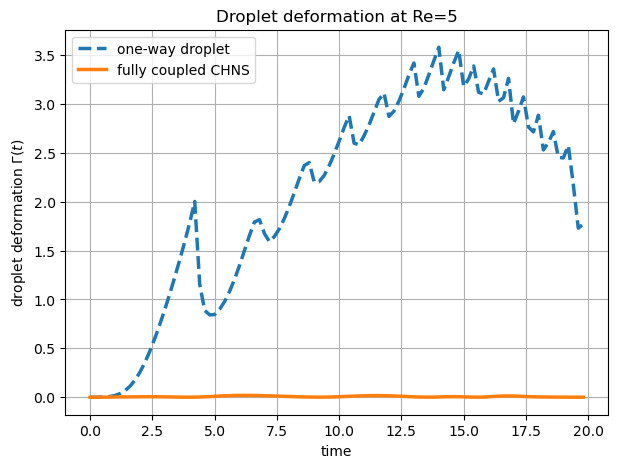

6.747840671628147e-05 3.5786433085500544
6.747848850374716e-05 0.018893826096580524
6.747840684706574e-05 3.6627676184845814
6.747849306787401e-05 0.025460342728397256
6.7478406828414e-05 3.984958543057595
6.747849651378424e-05 0.14641516581569225
6.747840693988039e-05 3.924533568356928
6.747849907262626e-05 0.06058685632822791


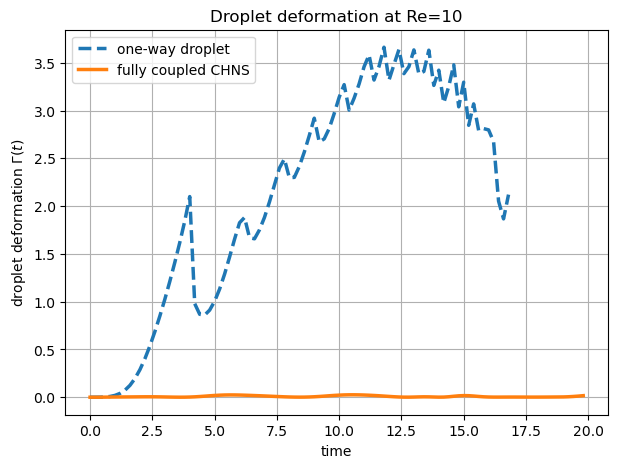

6.747840671628147e-05 3.5786433085500544
6.747848850374716e-05 0.018893826096580524
6.747840684706574e-05 3.6627676184845814
6.747849306787401e-05 0.025460342728397256
6.7478406828414e-05 3.984958543057595
6.747849651378424e-05 0.14641516581569225
6.747840693988039e-05 3.924533568356928
6.747849907262626e-05 0.06058685632822791


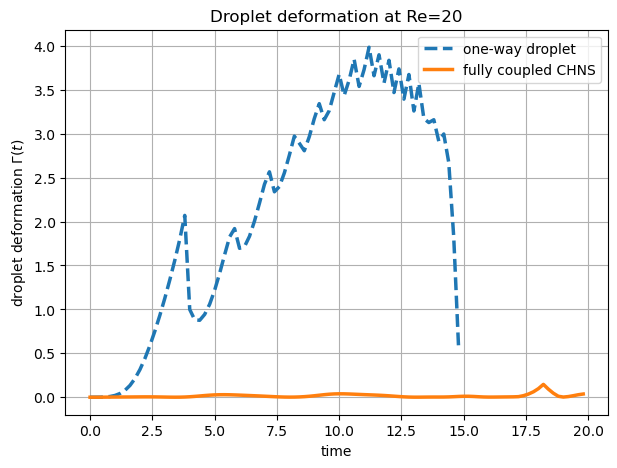

6.747840671628147e-05 3.5786433085500544
6.747848850374716e-05 0.018893826096580524
6.747840684706574e-05 3.6627676184845814
6.747849306787401e-05 0.025460342728397256
6.7478406828414e-05 3.984958543057595
6.747849651378424e-05 0.14641516581569225
6.747840693988039e-05 3.924533568356928
6.747849907262626e-05 0.06058685632822791


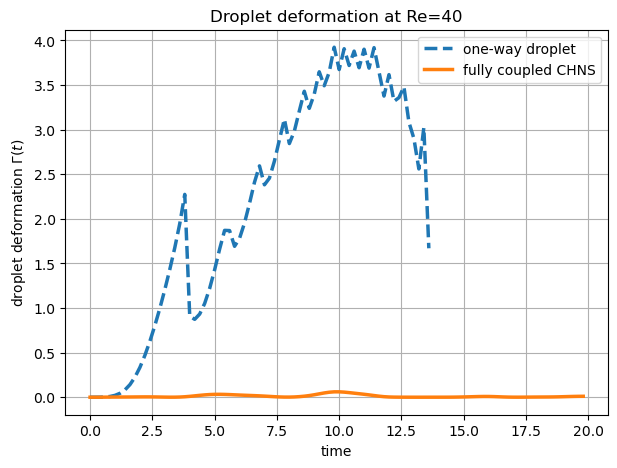

In [23]:
def plot_gamma_same_Re(all_results, Re_target):
    plt.figure(figsize=(7, 5))

    style_map = {
        "one-way droplet": {"linestyle": "--", "linewidth": 2.5},
        "fully coupled CHNS": {"linestyle": "-", "linewidth": 2.5},
    }

    for r in all_results:

        if r["case"] not in ["one-way droplet", "fully coupled CHNS"]:
            continue
        gamma = r["track"]["gamma"]

        print(gamma.min(), gamma.max())

        if not np.isclose(r["Re"], Re_target):
            continue

        t, gamma = get_gamma_signal(r)

        plt.plot(
            t,
            gamma,
            label=r["case"],
            **style_map.get(r["case"], {})
        )

    plt.xlabel("time")
    plt.ylabel(r"droplet deformation $\Gamma(t)$")
    plt.title(f"Droplet deformation at Re={Re_target}")
    plt.grid(True)
    plt.legend()
    plt.show()


for Re_target in target_Re_values:
    plot_gamma_same_Re(all_results, Re_target)

In [19]:
def plot_gamma_stat_vs_Re(gamma_statistics, stat_name):
    plt.figure(figsize=(7, 5))

    for case_name in gamma_statistics["case"].unique():

        df = gamma_statistics[
            gamma_statistics["case"] == case_name
        ].sort_values("Re")

        plt.plot(
            df["Re"],
            df[stat_name],
            marker="o",
            linewidth=2.5,
            label=case_name
        )

    plt.xlabel("Reynolds number")
    plt.ylabel(stat_name)
    plt.title(f"{stat_name} versus Reynolds number")
    plt.grid(True)
    plt.legend()
    plt.show()

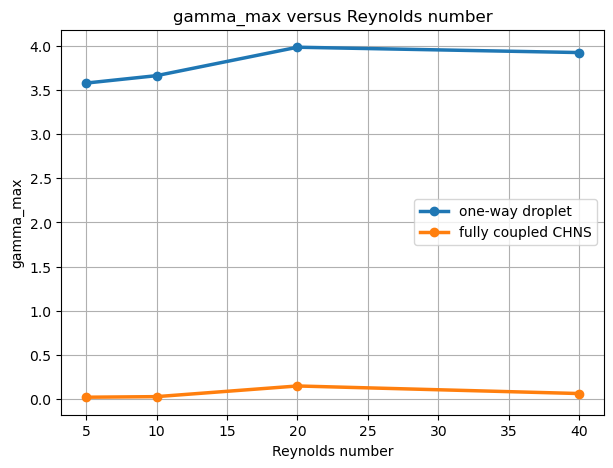

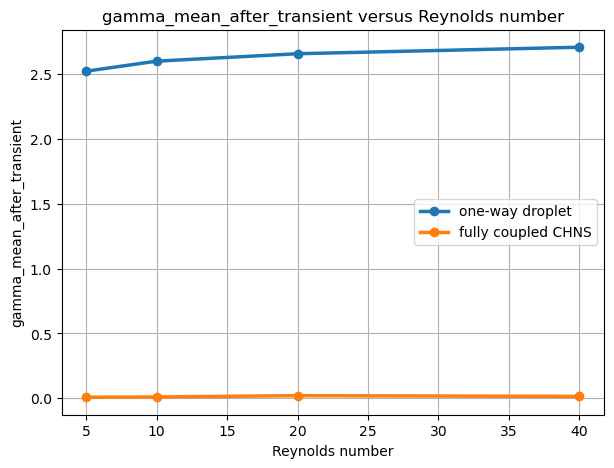

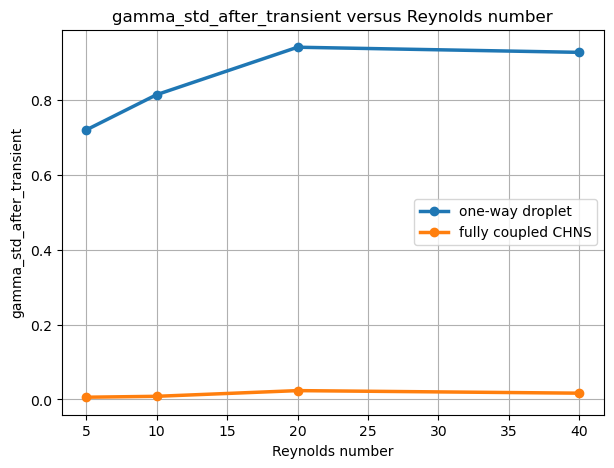

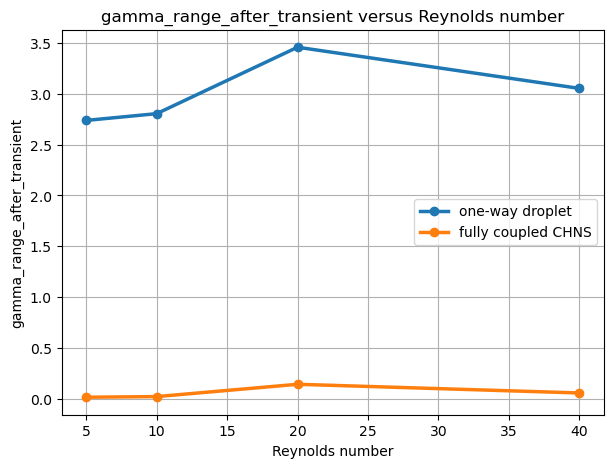

In [20]:
plot_gamma_stat_vs_Re(gamma_statistics, "gamma_max")
plot_gamma_stat_vs_Re(gamma_statistics, "gamma_mean_after_transient")
plot_gamma_stat_vs_Re(gamma_statistics, "gamma_std_after_transient")
plot_gamma_stat_vs_Re(gamma_statistics, "gamma_range_after_transient")

/var/folders/wd/trxjsq491pnd_0jjsv877_pm0000gn/T/ipykernel_25689/4077059089.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/wd/trxjsq491pnd_0jjsv877_pm0000gn/T/ipykernel_25689/4077059089.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


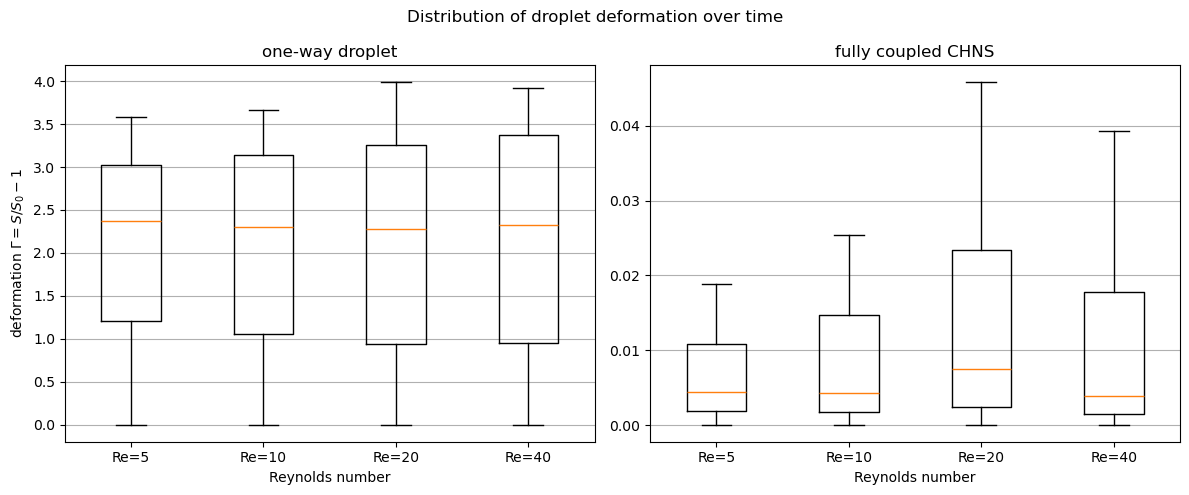

In [25]:
def plot_gamma_boxplot(all_results):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5),
        sharey=False
    )

    cases = [
        "one-way droplet",
        "fully coupled CHNS"
    ]

    for ax, case_name in zip(axes, cases):

        data = []
        labels = []

        subset = [
            r for r in all_results
            if r["case"] == case_name
        ]

        subset = sorted(subset, key=lambda r: r["Re"])

        for r in subset:

            t, gamma = get_gamma_signal(r)

            data.append(gamma)
            labels.append(f"Re={r['Re']:.0f}")

        ax.boxplot(
            data,
            labels=labels,
            showfliers=False
        )

        ax.set_title(case_name)
        ax.set_xlabel("Reynolds number")
        ax.grid(True, axis="y")

    axes[0].set_ylabel(
        r"deformation $\Gamma=S/S_0-1$"
    )

    plt.suptitle(
        "Distribution of droplet deformation over time"
    )

    plt.tight_layout()
    plt.show()


plot_gamma_boxplot(all_results)

In [22]:
def compare_gamma_statistics(gamma_statistics):
    one_way = gamma_statistics[
        gamma_statistics["case"] == "one-way droplet"
    ].set_index("Re")

    full = gamma_statistics[
        gamma_statistics["case"] == "fully coupled CHNS"
    ].set_index("Re")

    common_Re = sorted(set(one_way.index).intersection(set(full.index)))

    rows = []

    for Re in common_Re:
        rows.append({
            "Re": Re,

            "one_way_gamma_max": one_way.loc[Re, "gamma_max"],
            "full_gamma_max": full.loc[Re, "gamma_max"],
            "max_difference_full_minus_one_way":
                full.loc[Re, "gamma_max"] - one_way.loc[Re, "gamma_max"],

            "one_way_gamma_mean_ss": one_way.loc[Re, "gamma_mean_after_transient"],
            "full_gamma_mean_ss": full.loc[Re, "gamma_mean_after_transient"],
            "mean_difference_full_minus_one_way":
                full.loc[Re, "gamma_mean_after_transient"]
                - one_way.loc[Re, "gamma_mean_after_transient"],

            "one_way_gamma_std_ss": one_way.loc[Re, "gamma_std_after_transient"],
            "full_gamma_std_ss": full.loc[Re, "gamma_std_after_transient"],
            "std_difference_full_minus_one_way":
                full.loc[Re, "gamma_std_after_transient"]
                - one_way.loc[Re, "gamma_std_after_transient"],
        })

    return pd.DataFrame(rows)


gamma_comparison = compare_gamma_statistics(gamma_statistics)
gamma_comparison

,Re,one_way_gamma_max,full_gamma_max,max_difference_full_minus_one_way,one_way_gamma_mean_ss,full_gamma_mean_ss,mean_difference_full_minus_one_way,one_way_gamma_std_ss,full_gamma_std_ss,std_difference_full_minus_one_way
0,5.0,3.578643,0.018894,-3.559749,2.522490,0.007679,-2.514811,0.719715,0.005870,-0.713845
1,10.0,3.662768,0.025460,-3.637307,2.599910,0.009744,-2.590165,0.813921,0.008291,-0.805631
2,20.0,3.984959,0.146415,-3.838543,2.657200,0.019702,-2.637497,0.940656,0.023518,-0.917139
3,40.0,3.924534,0.060587,-3.863947,2.707355,0.014033,-2.693321,0.926960,0.016683,-0.910277
